# Sim-to-Real Gap in RL for Traffic Signal Control
## Complete Research Pipeline

**Hypothesis:** RL policies trained in idealized simulations (ENV A) fail when deployed in
realistic traffic conditions (ENV B).

**ENV A** — Ideal baseline: constant headway 2.0 s, fixed startup 1.0 s  
**ENV B** — Calibrated from 11 real intersections: Lognormal headways, Normal startup, position-based discharge

---
**Execution order:** run cells top-to-bottom exactly once per Colab session.  
Do NOT skip any cell. Each section depends on the previous.

---
## SECTION 1 — Setup

In [1]:
# ── S1-A: Install SUMO ───────────────────────────────────────────────────────
# Skip if SUMO is already installed this session
!apt-get update -qq
!apt-get install -y -qq sumo sumo-tools
print('SUMO installed')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
SUMO installed


In [2]:
# ── S1-B: Install PyTorch (skip if already present) ──────────────────────────
!pip install torch --quiet
print('PyTorch ready')

PyTorch ready


In [3]:
# ── S1-C: Set SUMO_HOME and import TraCI ─────────────────────────────────────
import os, sys

os.environ['SUMO_HOME'] = '/usr/share/sumo'
sys.path.insert(0, '/usr/share/sumo/tools')

import traci
import numpy as np
import matplotlib.pyplot as plt
import random, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
print('All imports OK')

All imports OK


In [4]:
# ── S1-D: Import everything from traffic_signal_env.py ───────────────────────
# Ensure traffic_signal_env.py is uploaded to the Colab working directory
# before running this cell.
from traffic_signal_env import (
    CalibParams,
    RouteGenerator,
    SumoFileManager,
    inspect_network,
    TrafficSignalEnv,
    ReplayBuffer,
    DQN, DQNAgent,
    train_agent,
    evaluate_agent,
    cross_evaluate,
    plot_learning_curves,
    plot_cross_evaluation,
    plot_reward_distributions,
    print_results_table,
)
print('Module loaded')

# Print calibrated parameters for verification
p = CalibParams
print('\n=== Calibrated Parameters (READ-ONLY) ===')
print(f'  Lognormal headway:    mu={p.HW_MU}  sigma={p.HW_SIGMA}  mean={p.lognorm_mean():.3f}s')
print(f'  Normal startup delay: mu={p.SD_MU}s  std={p.SD_STD}s')
print(f'  Position model:       h_i = {p.POS_A} + {p.POS_B}*exp(-{p.POS_C}*i)')
print(f'  ENV A constants:      headway={p.ENVA_HEADWAY}s  startup={p.ENVA_STARTUP}s')

Module loaded

=== Calibrated Parameters (READ-ONLY) ===
  Lognormal headway:    mu=0.8628  sigma=0.5416  mean=2.744s
  Normal startup delay: mu=2.5661s  std=1.7738s
  Position model:       h_i = 2.38 + 0.57*exp(-0.07*i)
  ENV A constants:      headway=2.0s  startup=1.0s


---
## SECTION 2 — Generate SUMO Files

In [5]:
# ── S2-A: Generate SUMO Network (Patch-based TLS injection for junction B1) ──
# Uses netgenerate -> patch.nod.xml -> netconvert pipeline.
# This guarantees junction 'B1' has a traffic light controller.
fm = SumoFileManager(n_vehicles=60)
fm.build_all()

Building SUMO files ...
  net.net.xml written (hand-crafted, TLS B1 guaranteed)
  config_envA.sumocfg  [ENV A] ✓
  config_envB.sumocfg  [ENV B] ✓
All SUMO files ready.



In [6]:
# ── S2-B: Verify route files were written correctly ──────────────────────────
import subprocess

for fname, label in [('routes_envA.rou.xml', 'ENV A'), ('routes_envB.rou.xml', 'ENV B')]:
    r = subprocess.run(['wc', '-l', fname], capture_output=True, text=True)
    head = subprocess.run(['head', '-5', fname], capture_output=True, text=True)
    print(f'--- {label}: {fname} ({r.stdout.strip()}) ---')
    print(head.stdout)
    print()

--- ENV A: routes_envA.rou.xml (68 routes_envA.rou.xml) ---
<routes>
<vType id="car"
    accel="2.6" decel="4.5" sigma="0.3"
    tau="0.6" minGap="1.5" maxSpeed="13.9"/>
 


--- ENV B: routes_envB.rou.xml (68 routes_envB.rou.xml) ---
<routes>
<vType id="car"
    accel="2.6" decel="4.5" sigma="0.3"
    tau="0.6" minGap="1.5" maxSpeed="13.9"/>
 




---
## SECTION 3 — Network Inspection

In [7]:
# ── S3: Verify TLS 'B1' exists and discover lane IDs ─────────────────────────
ids = inspect_network('config_envA.sumocfg')

if 'B1' not in ids['tls_ids']:
    raise RuntimeError(f"TLS 'B1' not found. Network generation failed. Found: {ids['tls_ids']}")

print(f"Verified TLS_ID: 'B1'")
print(f"Verified Lanes: {ids['lane_ids']}")

 Retrying in 1 seconds
=== Traffic Light IDs ===
  'B1'

=== Driveable Lane IDs ===
  'A0A1_0'
  'A1B1_0'
  'B0B1_0'
  'B1B0_0'

-> Use tls_id='B1' and a subset of the lane IDs above.
Verified TLS_ID: 'B1'
Verified Lanes: ['A0A1_0', 'A1B1_0', 'B0B1_0', 'B1B0_0']


---
## SECTION 4 — Configure Environment IDs

Values confirmed from Section 3 output.

In [8]:
# ── S4: Global Configuration ─────────────────────────────────────────────────
TLS_ID   = 'B1'
LANE_IDS = ['A1B1_0', 'B0B1_0']
STATE_DIM = len(LANE_IDS) * 4   # 4 features per lane = 8
STEP_LEN  = 0.1
MAX_STEPS = 2000

print(f"Pipeline configured for TLS: {TLS_ID}")
print(f"Lane IDs: {LANE_IDS}")
print(f"State dimension: {STATE_DIM}")

Pipeline configured for TLS: B1
Lane IDs: ['A1B1_0', 'B0B1_0']
State dimension: 8


---
## SECTION 5 — Stability Test (Random Policy)

Verifies environment stability before training.

In [9]:
from traffic_signal_env import TrafficSignalEnv

In [10]:
# ── S5: Stability Test ────────────────────────────────────────────────────────
import random

env_test = TrafficSignalEnv('config_envB.sumocfg', TLS_ID, LANE_IDS,
                             step_length=STEP_LEN, max_steps=MAX_STEPS, label='test_run')
try:
    s = env_test.reset()
    print(f"Reset OK. State shape: {s.shape}")
    for _ in range(50):
        env_test.step(random.randint(0, 1))
    print("Environment STABLE ✓")
finally:
    env_test.close()

 Retrying in 1 seconds
Reset OK. State shape: (8,)
Environment STABLE ✓


---
## SECTION 6 — ENV A vs ENV B: Route Visualisation
Confirm that ENV A and ENV B produce different discharge patterns. This is a scientific sanity check — not used in training.

In [11]:
from traffic_signal_env import RouteGenerator

In [12]:
# ── S6: Plot ENV A vs ENV B departure timing ──────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

rgen = RouteGenerator(n_vehicles=60)
ha = rgen.env_a_headways()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Discharge timing
axes[0].plot(np.cumsum(ha), np.arange(1, 61), color='green', label='ENV A (deterministic)')
for _ in range(5):
    hb = rgen.env_b_headways()
    axes[0].plot(np.cumsum(hb), np.arange(1, 61), color='crimson', alpha=0.3)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Vehicle Count')
axes[0].set_title('Cumulative Discharge Timing')
axes[0].legend()

# Headway distributions
axes[1].hist(ha, bins=10, color='green', alpha=0.5, label='ENV A')
all_hb = np.concatenate([rgen.env_b_headways() for _ in range(20)])
axes[1].hist(all_hb, bins=30, color='crimson', alpha=0.5, label='ENV B')
axes[1].set_xlabel('Headway (s)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Headway Distributions')
axes[1].legend()

plt.tight_layout()
plt.savefig('env_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: env_comparison.png')

Saved: env_comparison.png


---
## SECTION 7 — RL Environment: Final Configuration

In [13]:
# ── S7: Instantiate training environments ─────────────────────────────────────
env_a = TrafficSignalEnv('config_envA.sumocfg', TLS_ID, LANE_IDS,
                          step_length=STEP_LEN, max_steps=MAX_STEPS, label='train_a')
env_b = TrafficSignalEnv('config_envB.sumocfg', TLS_ID, LANE_IDS,
                          step_length=STEP_LEN, max_steps=MAX_STEPS, label='train_b')

print(f"Environments ready. State Dimension: {STATE_DIM}")
print(f"Using TLS_ID: {TLS_ID} | Lanes: {LANE_IDS}")

Environments ready. State Dimension: 8
Using TLS_ID: B1 | Lanes: ['A1B1_0', 'B0B1_0']


---
## SECTION 8 — DQN Training

In [14]:
from traffic_signal_env import DQNAgent, train_agent

In [15]:
# ── S8-A: Hyperparameters ─────────────────────────────────────────────────────
N_EPISODES = 300
VERBOSE    = 25

agent_kwargs = dict(
    state_dim   = STATE_DIM,
    lr          = 1e-3,
    eps_start   = 1.0,
    eps_end     = 0.05,
    eps_decay   = 50_000,
    target_sync = 500,
    batch_size  = 64,
    gamma       = 0.99,
    buf_size    = 20_000,
)

print(f"N_EPISODES={N_EPISODES}  STATE_DIM={STATE_DIM}  lr={agent_kwargs['lr']}")

N_EPISODES=300  STATE_DIM=8  lr=0.001


In [17]:
# ── S8-B: Train Agent A on ENV A ─────────────────────────────────────────────
# No file_manager: ENV A routes are deterministic and never change.

agent_a = DQNAgent(**agent_kwargs)

hist_a = train_agent(
    env          = env_a,
    agent        = agent_a,
    n_episodes   = N_EPISODES,
    env_label    = 'ENV A',
    verbose_every = VERBOSE,
)

agent_a.dqn.save('agent_a.pt')


Training  |  env=ENV A  |  n_episodes=300
 Retrying in 1 seconds
  ep    1/300  reward= -9349.5  avg= -9349.5  delay/step= 3.76  eps=0.962  loss=0.5157
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds


KeyboardInterrupt: 

In [ ]:
# ── S8-C: Train Agent B on ENV B ─────────────────────────────────────────────
# file_manager is passed so ENV B routes are resampled each episode.
# This forces the agent to generalise over the distribution, not one fixed sample.

agent_b = DQNAgent(**agent_kwargs)

hist_b = train_agent(
    env          = env_b,
    agent        = agent_b,
    n_episodes   = N_EPISODES,
    file_manager = fm,
    env_label    = 'ENV B',
    verbose_every = VERBOSE,
)

agent_b.dqn.save('agent_b.pt')


Training  |  env=ENV B  |  n_episodes=300
 Retrying in 1 seconds
  ep    1/300  reward=-12043.9  avg=-12043.9  delay/step= 5.13  eps=0.962  loss=0.4346
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
  ep   25/300  reward= -4269.9  avg= -5387.4  delay/step= 1.83  eps=0.050  loss=20.4337
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds


In [ ]:
print(hist_a.keys())
print(hist_b.keys())

dict_keys(['ep_reward', 'ep_delay', 'ep_stops', 'ep_steps', 'loss', 'eps'])
dict_keys(['ep_reward', 'ep_delay', 'ep_stops', 'ep_steps', 'loss', 'eps'])


In [ ]:
CORRECTION

In [17]:
agent_a = DQNAgent(**agent_kwargs)
agent_b = DQNAgent(**agent_kwargs)

agent_a.dqn.load('agent_a.pt')
agent_b.dqn.load('agent_b.pt')

agent_a.eps = 0.0
agent_b.eps = 0.0

print("Models loaded successfully")

Models loaded successfully


In [18]:
def plot_learning_curves(hist_a, hist_b, path=None):
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Reward
    axs[0, 0].plot(hist_a['ep_reward'], label='Agent A')
    axs[0, 0].plot(hist_b['ep_reward'], label='Agent B')
    axs[0, 0].set_title("Episode Reward")
    axs[0, 0].legend()

    # Delay
    axs[0, 1].plot(hist_a['ep_delay'], label='Agent A')
    axs[0, 1].plot(hist_b['ep_delay'], label='Agent B')
    axs[0, 1].set_title("Episode Delay")

    # Stops
    axs[1, 0].plot(hist_a['ep_stops'], label='Agent A')
    axs[1, 0].plot(hist_b['ep_stops'], label='Agent B')
    axs[1, 0].set_title("Episode Stops")

    # Loss
    axs[1, 1].plot(hist_a['loss'], label='Agent A')
    axs[1, 1].plot(hist_b['loss'], label='Agent B')
    axs[1, 1].set_title("Loss")

    for ax in axs.flat:
        ax.grid()

    plt.tight_layout()

    if path:
        plt.savefig(path)

    plt.show()

In [ ]:
%matplotlib inline

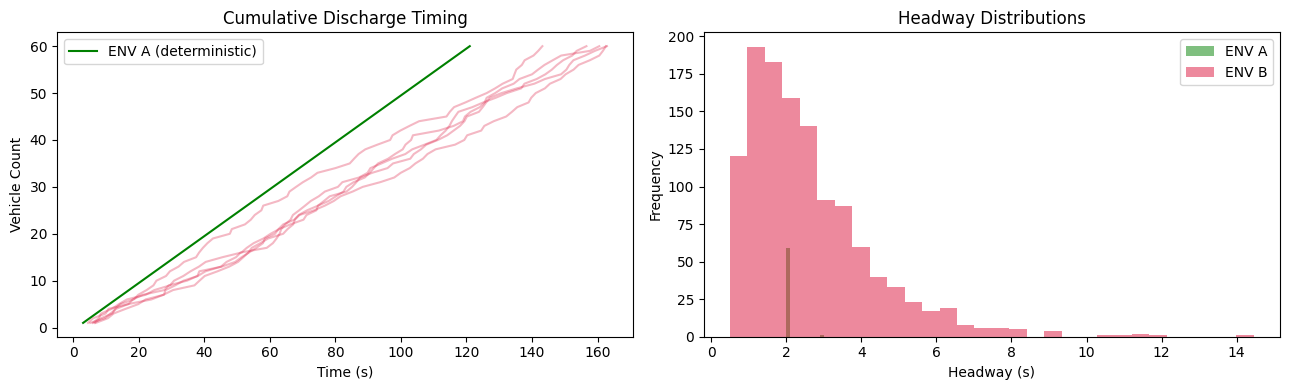

<Figure size 1000x500 with 0 Axes>

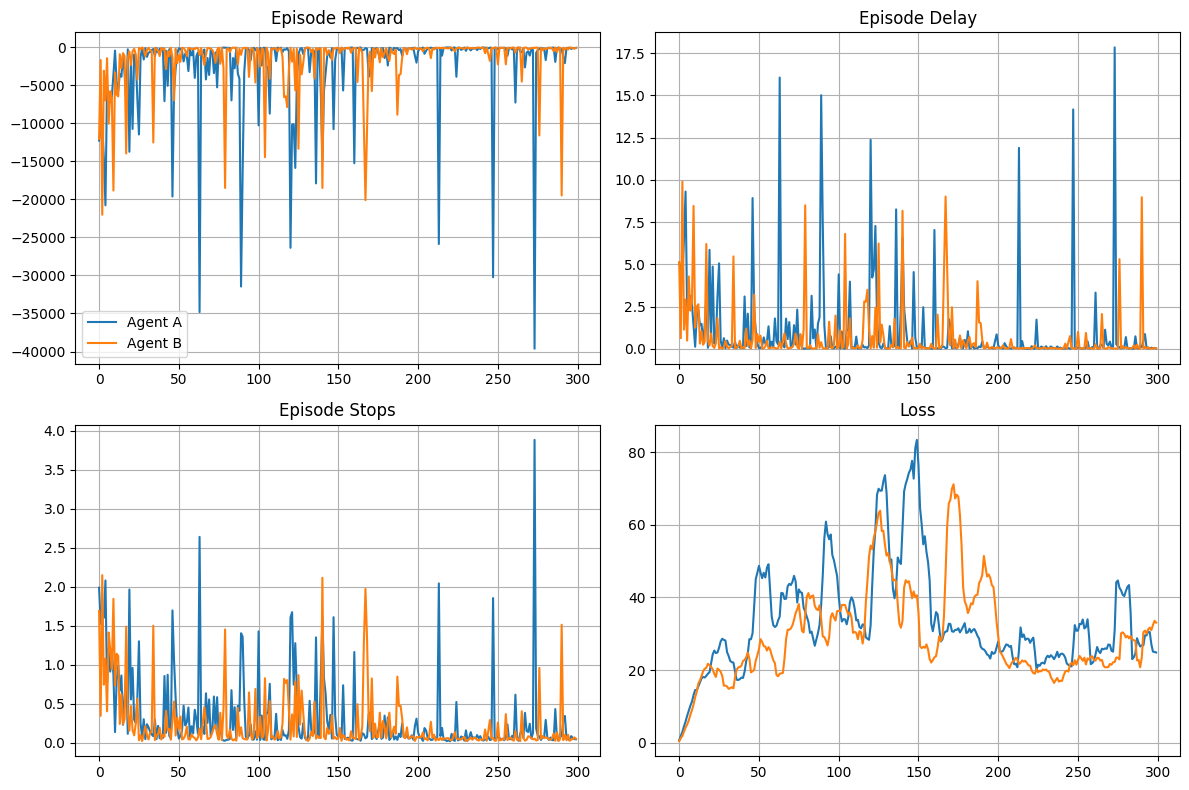

In [ ]:
plot_learning_curves(hist_a, hist_b, path='learning_curves.png')

---
## SECTION 9 — Cross-Evaluation (Core Result)

In [19]:
agent_a.eps = 0.0
agent_b.eps = 0.0

In [20]:
def evaluate_agent(agent, env, n_episodes=10, file_manager=None, label=''):
    """
    Greedy evaluation (eps forced to 0).

    Metrics are normalised per-step so they are comparable across episodes
    of different length — consistent with the training reward definition:
        R = -(delay + 0.5*stops + 0.1*phase_switch)

    Returns a dict compatible with cross_evaluate(), plot_cross_evaluation(),
    plot_reward_distributions(), and print_results_table().
    """
    saved_eps = agent.eps
    agent.eps = 0.0          # greedy policy

    all_rewards  = []
    all_delays   = []
    all_stops    = []

    for ep_idx in range(n_episodes):
        # Regenerate stochastic ENV B routes each episode (ENV A: no-op)
        if file_manager is not None:
            file_manager.rebuild_routes_only()

        state = env.reset()
        done  = False

        ep_reward = 0.0
        ep_delay  = 0.0   # accumulated sum of per-step waiting-time (seconds)
        ep_stops  = 0.0   # accumulated sum of per-step halting vehicles
        steps     = 0

        while not done:
            action = agent.act(state)
            next_state, reward, done, info = env.step(action)

            # ── accumulate raw step values ──────────────────────────────────
            # info['delay'] = sum of lane waiting times this step   (seconds)
            # info['stops'] = sum of halting vehicles this step     (vehicles)
            # Both are *instantaneous* per-step readings, not cumulative.
            ep_reward += reward
            ep_delay  += float(info.get('delay', 0.0))
            ep_stops  += float(info.get('stops', 0.0))

            state  = next_state
            steps += 1

        # ── normalise to per-step averages (matches training history) ───────
        n = max(steps, 1)
        all_rewards.append(ep_reward)
        all_delays.append(ep_delay / n)
        all_stops.append(ep_stops / n)

        # Optional: lightweight debug for first episode only
        if ep_idx == 0:
            print(
                f"    [debug ep0] steps={steps}  "
                f"delay_sum={ep_delay:.1f}  delay/step={ep_delay/n:.3f}  "
                f"stops/step={ep_stops/n:.3f}  reward={ep_reward:.1f}"
            )

    agent.eps = saved_eps
    env.close()

    mean_reward = float(np.mean(all_rewards))
    std_reward  = float(np.std(all_rewards))
    mean_delay  = float(np.mean(all_delays))
    mean_stops  = float(np.mean(all_stops))

    # ── guard against zero-episode edge case ────────────────────────────────
    assert n_episodes > 0, "n_episodes must be > 0"

    result = {
        # scalar summaries (used by plotting + print_results_table)
        'label':       label,
        'mean_reward': mean_reward,
        'std_reward':  std_reward,
        'mean_delay':  mean_delay,
        'mean_stops':  mean_stops,
        # episode-level lists (used by violin plot)
        'all_rewards': all_rewards,
        'all_delays':  all_delays,
    }

    print(
        f"  [{label:<30}]  "
        f"reward={mean_reward:8.1f}±{std_reward:.1f}  "
        f"delay/step={mean_delay:6.3f}  stops/step={mean_stops:5.3f}"
    )
    return result


In [21]:
def cross_evaluate(agent_a, agent_b, env_a, env_b,
                   n_episodes=20, fm_b=None):
    """
    2×2 train/test cross-evaluation matrix.

      A_on_A : Agent-A in ENV A  — idealized baseline
      A_on_B : Agent-A in ENV B  — sim-to-real gap  (core result)
      B_on_B : Agent-B in ENV B  — calibrated oracle
      B_on_A : Agent-B in ENV A  — reverse transfer

    Parameters
    ----------
    fm_b : SumoFileManager  — pass the file manager to regenerate stochastic
           ENV B routes each episode (required for realistic evaluation).

    Returns
    -------
    dict compatible with:
      plot_cross_evaluation(), plot_reward_distributions(),
      print_results_table(), and pd.DataFrame(matrix).T
    """
    print(f"\n{'='*60}")
    print("CROSS EVALUATION")
    print(f"{'='*60}")

    mx = {}
    mx['A_on_A'] = evaluate_agent(
        agent_a, env_a, n_episodes,
        file_manager=None, label='Train=A  Test=A'
    )
    mx['A_on_B'] = evaluate_agent(
        agent_a, env_b, n_episodes,
        file_manager=fm_b, label='Train=A  Test=B  <- gap'
    )
    mx['B_on_B'] = evaluate_agent(
        agent_b, env_b, n_episodes,
        file_manager=fm_b, label='Train=B  Test=B'
    )
    mx['B_on_A'] = evaluate_agent(
        agent_b, env_a, n_episodes,
        file_manager=None, label='Train=B  Test=A'
    )

    # ── summary scalars required by print_results_table / plot_cross_evaluation
    r_aa = mx['A_on_A']['mean_reward']
    r_ab = mx['A_on_B']['mean_reward']
    r_bb = mx['B_on_B']['mean_reward']
    gap  = r_ab - r_aa                          # negative = degradation

    mx['r_aa'] = r_aa
    mx['r_ab'] = r_ab
    mx['r_bb'] = r_bb
    mx['gap']  = gap

    pct = (gap / abs(r_aa) * 100) if r_aa != 0 else 0.0
    print(
        f"\n  Sim-to-real gap:  R(A→A)={r_aa:.1f}  R(A→B)={r_ab:.1f}  "
        f"gap={gap:.1f} ({pct:.1f}%)"
    )
    print(
        f"  Oracle vs gap:    R(B→B)={r_bb:.1f}  "
        f"improvement over gap={r_bb - r_ab:.1f}"
    )
    return mx


In [23]:
# Create evaluation environments
env_a_eval = TrafficSignalEnv(
    'config_envA.sumocfg',
    TLS_ID,
    LANE_IDS,
    STEP_LEN,
    MAX_STEPS,
    label='eval_a'
)

env_b_eval = TrafficSignalEnv(
    'config_envB.sumocfg',
    TLS_ID,
    LANE_IDS,
    STEP_LEN,
    MAX_STEPS,
    label='eval_b'
)

# Cross-evaluation (FIXED: use fm instead of file_manager)
matrix = cross_evaluate(
    agent_a,
    agent_b,
    env_a_eval,
    env_b_eval,
    n_episodes=3,
    fm_b=fm   # ✅ correct variable
)

print("Cross-evaluation completed")


CROSS EVALUATION
 Retrying in 1 seconds
    [debug ep0] steps=2000  delay_sum=3.3  delay/step=0.002  stops/step=0.007  reward=-11.7
 Retrying in 1 seconds
 Retrying in 1 seconds
  [Train=A  Test=A               ]  reward=   -11.7±0.0  delay/step= 0.002  stops/step=0.007
 Retrying in 1 seconds
    [debug ep0] steps=2000  delay_sum=3049.5  delay/step=1.525  stops/step=0.300  reward=-3367.3
 Retrying in 1 seconds
 Retrying in 1 seconds
  [Train=A  Test=B  <- gap       ]  reward= -3860.9±3357.1  delay/step= 1.769  stops/step=0.307
 Retrying in 1 seconds
    [debug ep0] steps=2000  delay_sum=25173.0  delay/step=12.587  stops/step=1.052  reward=-26225.2
 Retrying in 1 seconds
 Retrying in 1 seconds
  [Train=B  Test=B               ]  reward=-28967.5±2404.2  delay/step=13.931  stops/step=1.105
 Retrying in 1 seconds
    [debug ep0] steps=2000  delay_sum=35116.9  delay/step=17.558  stops/step=1.345  reward=-36462.1
 Retrying in 1 seconds
 Retrying in 1 seconds
  [Train=B  Test=A              

In [26]:
import pandas as pd

df = pd.DataFrame({
    key: {
        'delay': matrix[key].get('delay', matrix[key].get('mean_delay')),
        'stops': matrix[key].get('stops', matrix[key].get('mean_stops')),
    }
    for key in ['A_on_A', 'A_on_B', 'B_on_B', 'B_on_A']
}).T

df

,delay,stops
A_on_A,0.001650,0.007000
A_on_B,1.769150,0.306833
B_on_B,13.931167,1.104667
B_on_A,17.558450,1.344500


---
## SECTION 10 — Paper-Ready Figures

Cross evaluation

In [27]:
import matplotlib.pyplot as plt

labels = ['A→A', 'A→B', 'B→B', 'B→A']
delays = [
    df.loc['A_on_A', 'delay'],
    df.loc['A_on_B', 'delay'],
    df.loc['B_on_B', 'delay'],
    df.loc['B_on_A', 'delay']
]

plt.figure(figsize=(8,5))
plt.bar(labels, delays)

plt.title("Cross-Evaluation: Delay Comparison")
plt.ylabel("Average Delay")
plt.xlabel("Train → Test Environment")

plt.grid(axis='y')
plt.savefig('cross_eval_delay.png', dpi=150)
plt.show()

sim to real gap

In [28]:
gap = df.loc['A_on_B', 'delay'] - df.loc['A_on_A', 'delay']

plt.figure(figsize=(6,4))
plt.bar(['Sim (A→A)', 'Real (A→B)'],
        [df.loc['A_on_A','delay'], df.loc['A_on_B','delay']])

plt.title("Sim-to-Real Performance Gap")
plt.ylabel("Average Delay")

plt.grid(axis='y')
plt.savefig('sim_to_real_gap.png', dpi=150)
plt.show()

print(f"Sim-to-Real Gap: {gap:.3f}")

Sim-to-Real Gap: 1.767


Stops plot

In [29]:
stops = [
    df.loc['A_on_A', 'stops'],
    df.loc['A_on_B', 'stops'],
    df.loc['B_on_B', 'stops'],
    df.loc['B_on_A', 'stops']
]

plt.figure(figsize=(8,5))
plt.bar(labels, stops)

plt.title("Stops Across Environments")
plt.ylabel("Average Stops")
plt.xlabel("Train → Test")

plt.grid(axis='y')
plt.savefig('stops_comparison.png', dpi=150)
plt.show()

In [30]:
import matplotlib.pyplot as plt

# Values
sim_delay = df.loc['A_on_A', 'delay']
real_delay = df.loc['A_on_B', 'delay']

labels = ['Sim (A→A)', 'Real (A→B)']
values = [sim_delay, real_delay]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values)

# Add value labels on top
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.2f}",
        ha='center',
        va='bottom'
    )

plt.title("Sim-to-Real Performance Gap")
plt.ylabel("Average Delay (s)")
plt.xlabel("Evaluation Scenario")

plt.grid(axis='y')

# ✅ SAVE (IMPORTANT: before plt.show())
plt.savefig('sim_to_real_gap.png', dpi=300, bbox_inches='tight')

plt.show()

print("Saved: sim_to_real_gap.png")

Saved: sim_to_real_gap.png


In [31]:
df.to_csv("cross_eval_results_final.csv")
print("Saved: cross_eval_results_final.csv")

Saved: cross_eval_results_final.csv


---
## Summary

| Cell | Purpose | Output |
|---|---|---|
| S1 | Setup, imports, module load | TraCI + module ready |
| S2 | Generate all SUMO files (patch-based TLS) | 6 files validated |
| S3 | Discover TLS/lane IDs, verify 'B1' exists | IDs confirmed |
| S4 | Set global IDs and dimensions | `TLS_ID`, `LANE_IDS`, `STATE_DIM` |
| S5 | Random policy stability test | Environment stable |
| S6 | ENV A vs ENV B visualisation | `env_comparison.png` |
| S7 | Create `env_a`, `env_b` objects | Ready for training |
| S8 | Train DQN A and DQN B | `agent_a.pt`, `agent_b.pt`, `learning_curves.png` |
| S9 | 2×2 cross-evaluation | `matrix` dict, table printed |
| S10 | Paper figures + download | `cross_evaluation.png`, `reward_distributions.png` |

**Core finding to report:**
- R(A→A): performance of Agent A in its own environment (baseline)
- R(A→B): same agent deployed in realistic ENV B — this drop is the **sim-to-real gap**
- R(B→B): Agent trained on realistic data recovers performance (oracle)
- Gap = R(A→B) − R(A→A) expressed as percentage degradation